Found 1600 images belonging to 4 classes.

Generating Grad-CAM for mobilenetv2...


/tmp/ipykernel_58/1763512203.py:19: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inp)
I0000 00:00:1785654277.708634      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785654277.711317      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


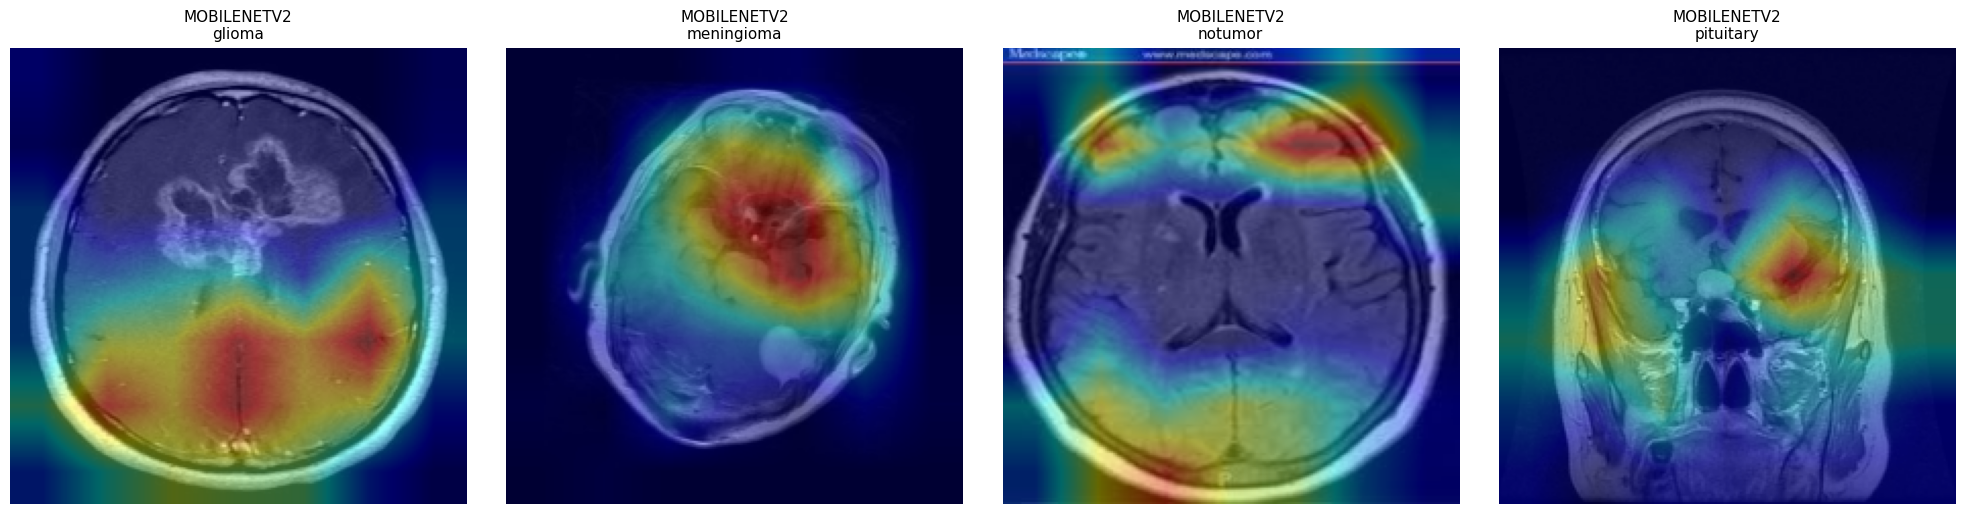

Saved: gradcam_mobilenetv2.png

Generating Grad-CAM for resnet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_159']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


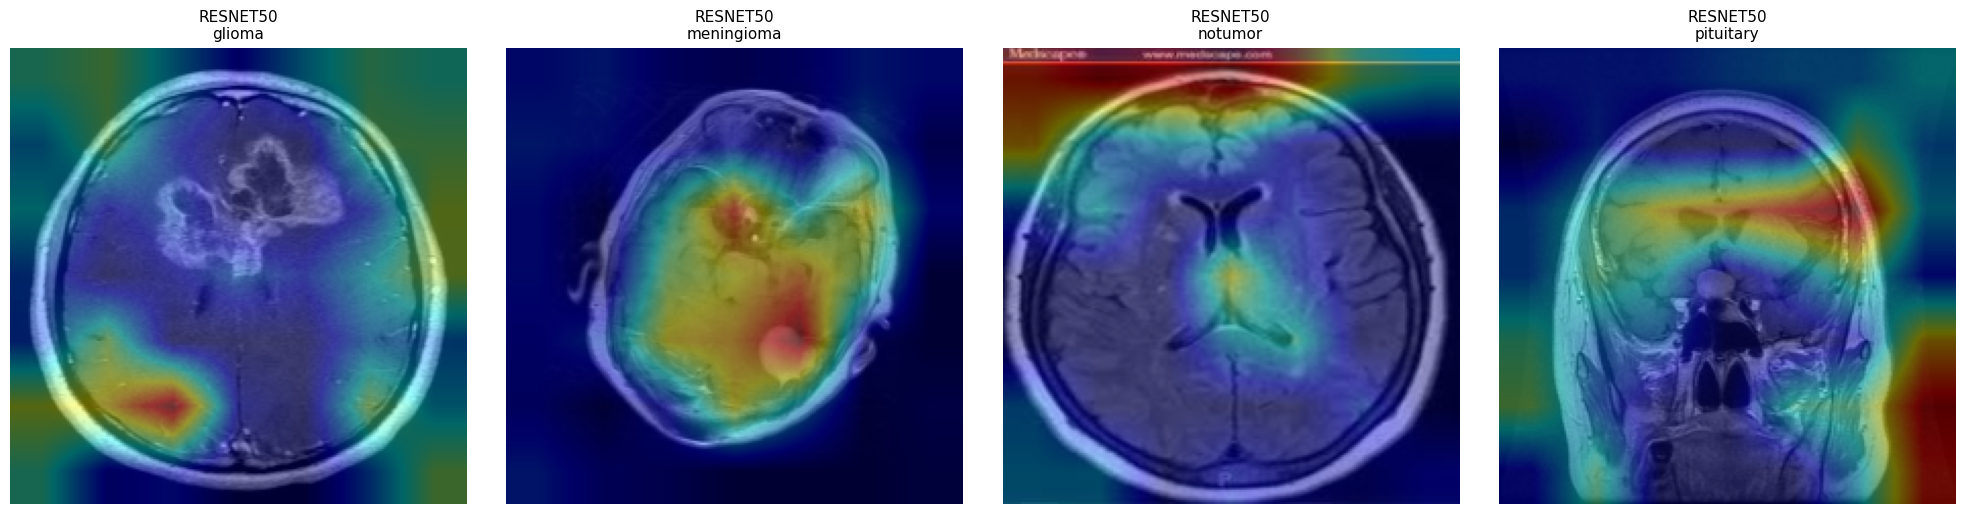

Saved: gradcam_resnet50.png

Generating Grad-CAM for efficientnetb0...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_339']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


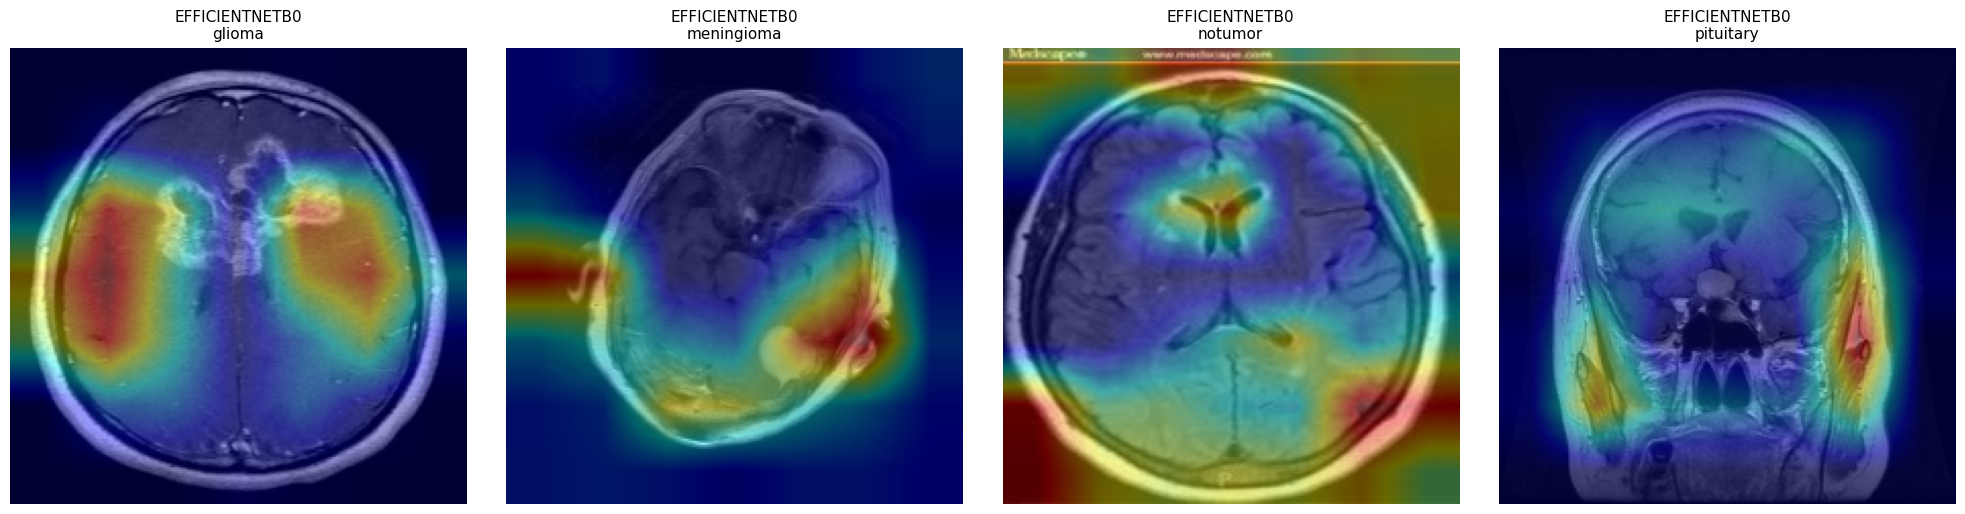

Saved: gradcam_efficientnetb0.png

✅ All Grad-CAM figures saved to /kaggle/working/


In [1]:
import os, numpy as np, tensorflow as tf, cv2
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as pre_mob
from tensorflow.keras.applications.resnet50 import preprocess_input as pre_res
from tensorflow.keras.applications.efficientnet import preprocess_input as pre_eff
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

BASE = '/kaggle/input/datasets/ekrasafdar/brain-tumor-mri'
TEST_DIR = os.path.join(BASE, 'Testing')
IMG_SIZE = (224, 224)

# ========== Grad-CAM implementation ==========
def make_gradcam_model(base_model_name):
    inp = layers.Input(shape=(224, 224, 3))
    if base_model_name == 'mobilenetv2':
        base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inp)
        last_conv = 'out_relu'  # MobileNetV2 last conv
        pre = pre_mob
    elif base_model_name == 'resnet50':
        base = ResNet50(weights='imagenet', include_top=False, input_tensor=inp)
        last_conv = 'conv5_block3_out'  # ResNet50 last conv
        pre = pre_res
    else:
        base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=inp)
        last_conv = 'top_activation'  # EfficientNetB0 last conv
        pre = pre_eff
    
    # Same head as your training code
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(4, activation='softmax')(x)
    model = keras.Model(inp, out)
    
    # Build gradcam model
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[base.get_layer(last_conv).output, model.output]
    )
    return grad_model, pre, last_conv

def gradcam(grad_model, img_array, pred_index=None):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def overlay_heatmap(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)
    return cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)

# ========== Generate one sample per class per model ==========
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
test_gen = ImageDataGenerator().flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=1, 
    class_mode='categorical', shuffle=False)

# Pick one representative image per class
representatives = {}
for i in range(len(test_gen)):
    x, y = test_gen[i]
    cls = np.argmax(y[0])
    name = class_names[cls]
    if name not in representatives:
        representatives[name] = (x[0], test_gen.filepaths[i])
    if len(representatives) == 4:
        break

# Run Grad-CAM for all 3 models
for model_name in ['mobilenetv2', 'resnet50', 'efficientnetb0']:
    print(f"\nGenerating Grad-CAM for {model_name}...")
    grad_model, pre, _ = make_gradcam_model(model_name)
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for idx, cls in enumerate(class_names):
        img_raw, path = representatives[cls]
        img_pre = pre(img_raw.copy())  # apply model-specific preprocessing
        img_batch = np.expand_dims(img_pre, axis=0)
        
        heatmap = gradcam(grad_model, img_batch)
        overlay = overlay_heatmap(path, heatmap)
        
        axes[idx].imshow(overlay)
        axes[idx].set_title(f'{model_name.upper()}\n{cls}', fontsize=11)
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/gradcam_{model_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: gradcam_{model_name}.png")

print("\n✅ All Grad-CAM figures saved to /kaggle/working/")

In [ ]:
import os, numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as pre_res
from tensorflow.keras.applications.efficientnet import preprocess_input as pre_eff
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import f1_score

BASE = '/kaggle/input/datasets/ekrasafdar/brain-tumor-mri'
TRAIN_DIR = os.path.join(BASE, 'Training')
TEST_DIR  = os.path.join(BASE, 'Testing')

def mc_model(name):
    inp = layers.Input(shape=(224, 224, 3))
    if name == 'resnet50':
        base = ResNet50(weights='imagenet', include_top=False, input_tensor=inp)
        pre = pre_res
    else:
        base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=inp)
        pre = pre_eff
    
    base.trainable = True
    for L in base.layers[:-50]: L.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x, training=True)  # MC Dropout
    out = layers.Dense(4, activation='softmax')(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return m, pre

# Train ResNet50 MC (seed 42 only, ~15 min)
for model_name in ['resnet50', 'efficientnetb0']:
    print(f"\n{'='*50}\nMC Dropout: {model_name.upper()}\n{'='*50}")
    model, pre = mc_model(model_name)
    
    tr_aug = ImageDataGenerator(preprocessing_function=pre, rotation_range=20,
        width_shift_range=0.15, height_shift_range=0.15, zoom_range=0.15,
        horizontal_flip=True, brightness_range=[0.8, 1.2], validation_split=0.2)
    tr = tr_aug.flow_from_directory(TRAIN_DIR, target_size=(224,224), batch_size=32,
        class_mode='categorical', subset='training', seed=42)
    val = tr_aug.flow_from_directory(TRAIN_DIR, target_size=(224,224), batch_size=32,
        class_mode='categorical', subset='validation', shuffle=False, seed=42)
    te = ImageDataGenerator(preprocessing_function=pre).flow_from_directory(
        TEST_DIR, target_size=(224,224), batch_size=32, class_mode='categorical', shuffle=False)
    
    cb = [
        keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
    ]
    model.fit(tr, validation_data=val, epochs=30, callbacks=cb, verbose=1)
    
    te.reset(); loss, acc = model.evaluate(te, verbose=0)
    te.reset(); yp = np.argmax(model.predict(te, verbose=0), axis=1)
    yt = te.classes
    print(f"{model_name} MC — Accuracy: {acc*100:.2f}% | F1: {f1_score(yt, yp, average='weighted')*100:.2f}%")